In [11]:
from langgraph.graph import StateGraph , START , END
from langgraph.checkpoint.memory import MemorySaver, InMemorySaver
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing_extensions import TypedDict

In [12]:
load_dotenv()

llm = ChatOpenAI()

In [13]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explaination: str

In [14]:
def generate_joke(state: JokeState)->JokeState:
    prompt = f"Generate a joke on the topic {state['topic']}"
    response = llm.invoke(prompt).content

    return {'joke':response}

In [15]:
def generate_explaination(state:JokeState)->JokeState:
    prompt = f"Write an explaination for the joke - {state['joke']}"
    response = llm.invoke(prompt)
    return {'explaination': response}

In [18]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_explaination", generate_explaination)


graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explaination')
graph.add_edge('generate_explaination', END)


checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)


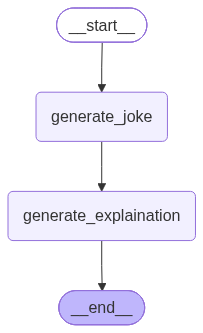

In [19]:
workflow

In [20]:
config = {"configurable":{"thread_id": "1"}}

workflow.invoke({'topic':'pizza'}, config=config)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the party? \nBecause it wanted to get a pizza the action!',
 'explaination': AIMessage(content='This joke plays on the word "piece" sounding like "peace" in the context of wanting to be a part of the action at a party. The pizza is personified as wanting to be involved and have a slice of the fun at the party, so it goes to join in on the action. "Pizza the action" is a play on the phrase "piece of the action," meaning the pizza wanted to be a part of the excitement and enjoyment at the party.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 35, 'total_tokens': 130, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_f

In [21]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party? \nBecause it wanted to get a pizza the action!', 'explaination': AIMessage(content='This joke plays on the word "piece" sounding like "peace" in the context of wanting to be a part of the action at a party. The pizza is personified as wanting to be involved and have a slice of the fun at the party, so it goes to join in on the action. "Pizza the action" is a play on the phrase "piece of the action," meaning the pizza wanted to be a part of the excitement and enjoyment at the party.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 35, 'total_tokens': 130, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-tur